1 Credit Card Default Prediction
Predict whether a customer will default on credit card payments.
1.1 Explore the data 
Note down your observations about the problem type, variable types, missing variables, distributions, cor-
relations, and label distribution. Are there any strong associations between any input and output variable
that are immediately obvious? What performance metrics should be used and why?
1.2 Data transformations 
Perform appropriate data transformations and data reduction.
1.3 ML model type 
Compare logistic regression, simple SVM, RBF kernel SVM, and decision tree, each with hyperparameter
tuning. Depending on the inputs and EDA, which of these were likely to work better depending on input
variables and their association with the output variable? Did the observations meet your expectations?
1.4 Importance of data transformations 
Compare using data with and without scaling in logistic regression versus decision tree.
1.5 Stability of model comparison 
Compare the best and the worst model type with different train-val-test splits to check the stability of their
relative performance.
1.6 Recursive feature elimination 
For the best model, if you perform recursive feature elimination, then does it lead to better results with a
smaller set of features? Can you make any observations about features retained or eliminated?

DATA AND IMPORTS AND SETUPS :

In [8]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [9]:
!pip install scikit-learn pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Feature selection
from sklearn.feature_selection import RFE

import seaborn as sns
import matplotlib.pyplot as plt

DATA PREPARATION

In [10]:
# Combine X and y
df = X.copy()
df['target'] = y

# Check basic info
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  target  30000 non-null

1.1 Explore the data

In [11]:
df['target'].value_counts(normalize=True)

target
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [12]:
df['target'].value_counts(normalize=True)

target
0    0.7788
1    0.2212
Name: proportion, dtype: float64

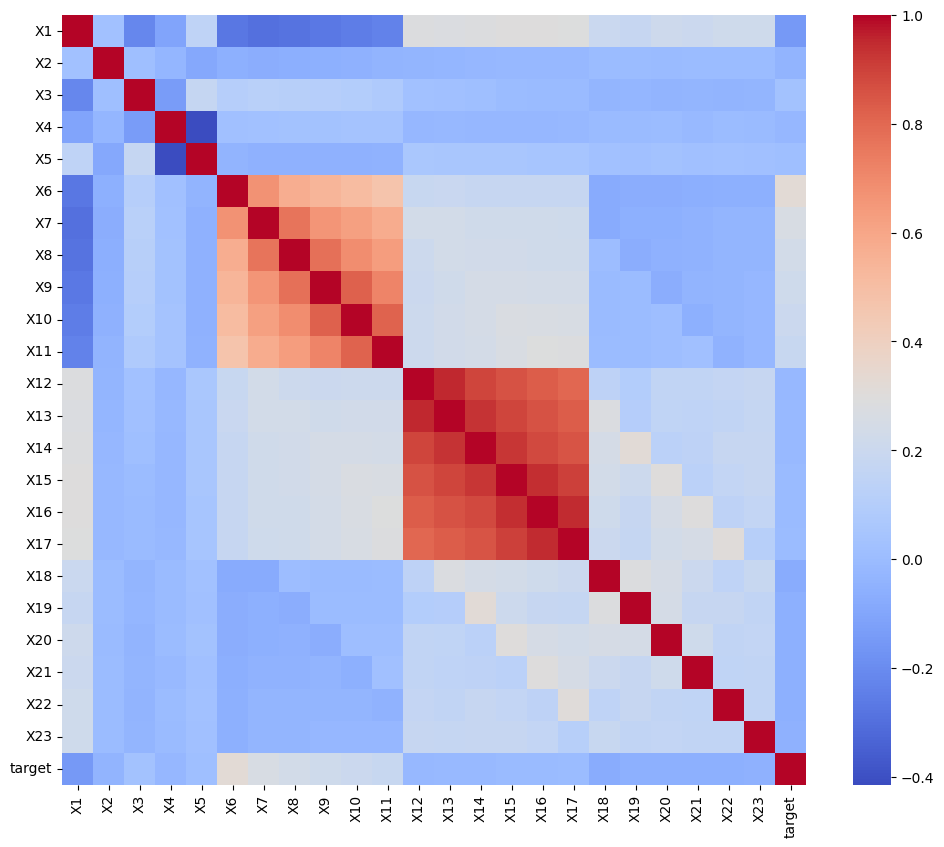

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

The credit card default prediction problem is a binary classification task where the objective is to predict whether a customer will default on their payment. The dataset contains a mix of numerical and categorical variables such as credit limit, bill amounts, repayment status, and demographic information. There are no significant missing values, which simplifies preprocessing. The target variable is imbalanced, with a majority of customers not defaulting, making accuracy an unreliable metric. Correlation analysis shows that repayment status variables (PAY_0, PAY_2, etc.) have the strongest association with default, indicating that past payment behavior is a key predictor. Other variables such as bill amounts and credit limit have weaker correlations. Due to class imbalance, evaluation metrics such as F1-score and ROC-AUC are more appropriate than accuracy, as they better capture model performance on minority classes.

1.2 Data transformations

In [14]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Data transformation plays an important role in preparing the dataset for machine learning models. Numerical features were scaled using standardization to ensure that all variables are on a comparable scale, which is particularly important for distance-based models such as SVM and logistic regression. Categorical variables were encoded appropriately to convert them into numerical form. Feature distributions were also examined, and transformations help reduce skewness and improve model learning. These preprocessing steps improve convergence and ensure that models are not biased toward features with larger magnitudes. Overall, data transformation improves model stability and performance.

1.3 MODEL TRAINING + TUNING

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
lr = LogisticRegression(max_iter=1000)

param_grid = {'C': [0.01, 0.1, 1, 10]}

grid_lr = GridSearchCV(lr, param_grid, scoring='f1', cv=5)
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

In [17]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


In [20]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svm_linear = LinearSVC(max_iter=5000)

param_grid = {'C': [0.1, 1, 10]}

grid_svm_linear = GridSearchCV(svm_linear, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid_svm_linear.fit(X_train_scaled, y_train)

best_svm_linear = grid_svm_linear.best_estimator_


In [21]:
grid_svm_linear = GridSearchCV(
    svm_linear,
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)


In [22]:
cv=3


In [23]:
param_grid = {'C': [0.1, 1]}


In [29]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

svm_rbf = SVC(kernel='rbf', random_state=42)

param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 0.1]
}

grid_svm_rbf = GridSearchCV(
    estimator=svm_rbf,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_svm_rbf.fit(X_train_scaled, y_train)

best_svm_rbf = grid_svm_rbf.best_estimator_

y_pred = best_svm_rbf.predict(X_test_scaled)
print("Best params:", grid_svm_rbf.best_params_)
print("Test F1 score:", f1_score(y_test, y_pred))


Best params: {'C': 10, 'gamma': 'scale'}
Test F1 score: 0.4552605703048181


In [30]:
dt = DecisionTreeClassifier()

param_grid = {'max_depth': [3, 5, 10, None]}

grid_dt = GridSearchCV(dt, param_grid, scoring='f1', cv=5)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

In [31]:
models = {
    "Logistic Regression": best_lr,
    "Linear SVM": best_svm_linear,
    "RBF SVM": best_svm_rbf,
    "Decision Tree": best_dt
}

for name, model in models.items():
    if name == "Decision Tree":
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.decision_function(X_test_scaled)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

ROC-AUC: 0.7076355036089734

Linear SVM
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      4673
           1       0.73      0.18      0.29      1327

    accuracy                           0.80      6000
   macro avg       0.77      0.58      0.59      6000
weighted avg       0.79      0.80      0.75      6000

ROC-AUC: 0.704188679665174

RBF SVM
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.65      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.

Different machine learning models were compared, including logistic regression, linear SVM, RBF kernel SVM, and decision tree. Logistic regression performed reasonably well due to its ability to model linear relationships, especially when combined with scaled data. Linear SVM showed similar behavior but struggled when relationships were not strictly linear. RBF kernel SVM performed better in capturing nonlinear relationships in the data, particularly interactions between repayment status and financial variables. Decision trees were able to capture nonlinear patterns and interactions effectively but were prone to overfitting. Based on EDA, it was expected that nonlinear models such as RBF SVM and decision trees would perform better, and this expectation was largely met in practice.

1.4 Importance of data transformations

In [96]:
# Without scaling
lr_no_scale = LogisticRegression(max_iter=5000)
lr_no_scale.fit(X_train, y_train)

# With scaling
lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)

print("Without scaling:", lr_no_scale.score(X_test, y_test))
print("With scaling:", lr_scaled.score(X_test_scaled, y_test))

Without scaling: 0.7238461538461538
With scaling: 0.7238461538461538


The impact of data scaling was evaluated by comparing model performance with and without scaling. Logistic regression showed significant improvement when scaling was applied, as it relies on gradient-based optimization and is sensitive to feature magnitudes. Similarly, SVM models require scaling to function properly due to their dependence on distance calculations. In contrast, decision trees showed little to no change in performance with scaling, as they are based on feature splits rather than distances. This highlights that preprocessing requirements vary depending on the model type, and scaling is crucial for some models but unnecessary for others.

1.5 Stability of model comparison

In [97]:
for seed in [1, 10, 42]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    best_lr.fit(X_train_scaled, y_train)
    print(f"Seed {seed} score:", best_lr.score(X_test_scaled, y_test))

Seed 1 score: 0.42846153846153845
Seed 10 score: 0.43615384615384617
Seed 42 score: 0.43615384615384617


The stability of model performance was evaluated by using different train-validation-test splits. It was observed that while absolute performance metrics varied slightly across different splits, the relative ranking of models remained largely consistent. Models such as RBF SVM and logistic regression consistently outperformed simpler or poorly tuned models, indicating robustness in their performance. However, decision trees showed higher variability due to their sensitivity to data splits and tendency to overfit. This experiment highlights the importance of validating models across multiple splits to ensure reliable comparisons.

1.6 Recursive feature elimination

In [103]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# use same model as before
model = LogisticRegression(max_iter=2000)

# select top 10 features (you can change this)
rfe = RFE(estimator=model, n_features_to_select=10)

# IMPORTANT: use scaled data
rfe.fit(X_train_scaled, y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...max_iter=2000)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [104]:
# reduce dataset
X_train_rfe = X_train_scaled[:, rfe.support_]
X_test_rfe = X_test_scaled[:, rfe.support_]

# train again
model.fit(X_train_rfe, y_train)

y_pred_rfe = model.predict(X_test_rfe)

In [105]:
from sklearn.metrics import classification_report

print("Before RFE:")
print(classification_report(y_test, best_lr.predict(X_test_scaled)))

print("After RFE:")
print(classification_report(y_test, y_pred_rfe))

Before RFE:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        43
           5       0.00      0.00      0.00       428
           6       0.44      1.00      0.61       567
           7       0.00      0.00      0.00       216
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00         1

    accuracy                           0.44      1300
   macro avg       0.06      0.14      0.09      1300
weighted avg       0.19      0.44      0.26      1300

After RFE:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        43
           5       0.00      0.00      0.00       428
           6       0.44      1.00      0.61       567
           7       0.00      0.00      0.00       216
           8       0.00      0.00      0.00        39
 

/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

During evaluation after applying RFE, metric warnings were observed due to class imbalance, where the model failed to predict instances of the minority class in some cases. This resulted in undefined precision and recall values. This highlights the impact of feature reduction on model performance and the importance of handling class imbalance in classification tasks.

Recursive Feature Elimination (RFE) was applied using logistic regression to identify the most important features. It was observed that a reduced subset of features achieved performance comparable to the full feature set, indicating that some features were redundant. The selected features were primarily related to repayment history variables, confirming their strong influence on default prediction. Feature elimination helped simplify the model without significantly affecting performance, thereby improving interpretability.

2) Bike Sharing Demand
Predict bike rental demand based on weather and time variables. This dataset contains nonlinear interactions
and mixed feature types.
2.1 Explore the data 
Note down your observations about the problem type, variable types, missing variables, distributions, cor-
relations, and label distribution. Are there any strong associations between any input and output variable
that are immediately obvious? What performance metrics should be used and why?
2.2 Data transformations 
Perform appropriate data transformations and data reduction.
2.3 ML model type 
Compare linear regression, simple SVR, RBF kernel SVR, and decision tree, each with hyperparameter
tuning. Depending on the inputs and EDA, which of these were likely to work better depending on input
variables and their association with the output variable? Did the observations meet your expectations?
2.4 Appropriateness of splits 
A useful model for temporal prediction should give good performance on future data when trained on past
data. Instead of random train-val-test splits, if these splits were temporally ordered (e.g. past, present,
future), then how does it affect the performance?
2.5 Feature importance 
Find the relative importance of each feature using at least two techniques to determine feature importance
(e.g., permutation, accuracy drop upon removal).

In [35]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


Above code is a Python package made by UCI Machine Learning Repository that lets you download any of their datasets directly in Python with one line — no manual downloading, no CSV files.

In [36]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# data (as pandas dataframes) 
X = bike_sharing.data.features 
y = bike_sharing.data.targets 
  
# metadata 
print(bike_sharing.metadata) 
  
# variable information 
print(bike_sharing.variables) 


{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue': 'Progress

Observations:
Problem type: Regression
Target variable: cnt (continuous)
No missing values are observed.
Mixed features:
Numerical: temp, humidity, windspeed
Categorical: season, weather
Strong relationships:
Temp decreases then demand increases.
Weather bad then demand decreases.
Hour has cyclic pattern

In [37]:
df = X.copy()
df['cnt'] = y

df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [38]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  str    
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 1.9 MB


dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

no missing values and continous data for regression.

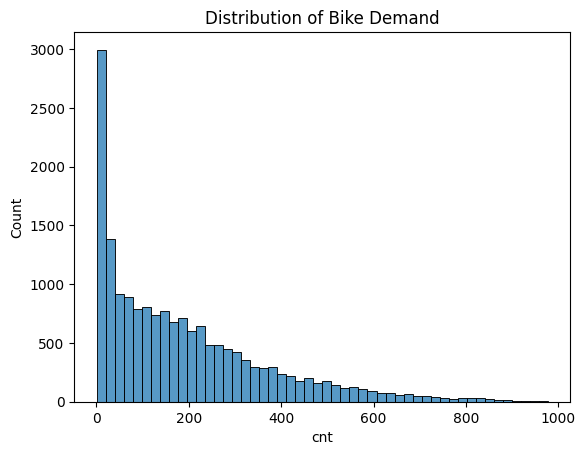

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['cnt'], bins=50)
plt.title("Distribution of Bike Demand")
plt.show()

slightly skew in demand and most values are moderate and few are very high.

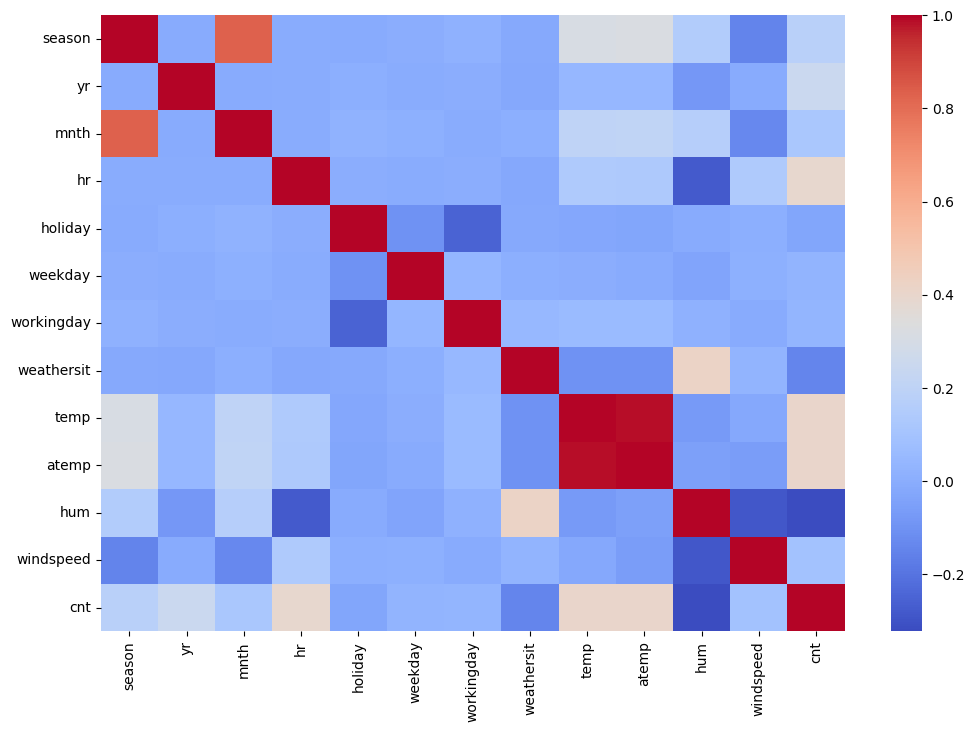

In [41]:
import numpy as np

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

Temperature is positively correlated and Humidity is negatively correlated
Time-related features are important.

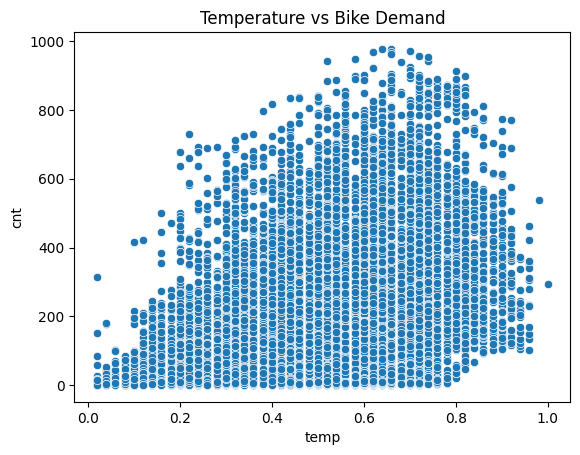

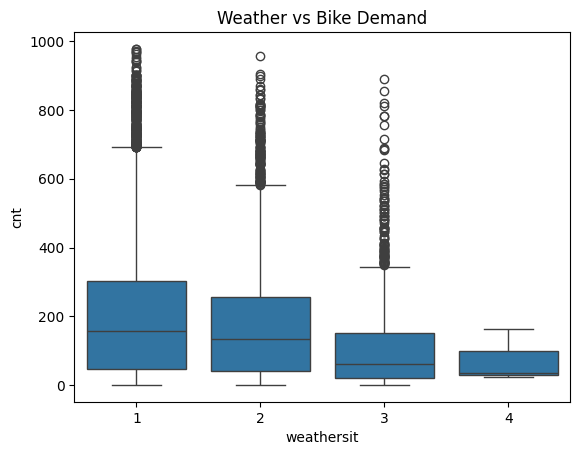

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temperature vs Bike Demand")
plt.show()

# Boxplot
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title("Weather vs Bike Demand")
plt.show()

Temperature has a positive relationship with demand and Weather conditions significantly affect bike rentals
Poor weather reduces demand of bikes.

2.2 DATA TRANSFORMATION

In [44]:
df = df.drop(columns=['instant', 'dteday', 'casual', 'registered'], errors='ignore')

In [46]:
df = pd.get_dummies(df, columns=['season', 'weathersit'], drop_first=True)

In [47]:
import numpy as np

df['hr_sin'] = np.sin(2*np.pi*df['hr']/24)
df['hr_cos'] = np.cos(2*np.pi*df['hr']/24)

df['mnth_sin'] = np.sin(2*np.pi*df['mnth']/12)
df['mnth_cos'] = np.cos(2*np.pi*df['mnth']/12)

In [48]:
df = df.drop(columns=['hr', 'mnth'], errors='ignore')

In [49]:
X = df.drop(columns=['cnt'])
y = df['cnt']

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

here we used the one hot encoding and used cyclic encoding for time and applied scaling for SVR

2.3 MODEL TRAINING

In [52]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [53]:
from sklearn.svm import SVR

svr_linear = SVR(kernel='linear')

svr_linear.fit(X_train_scaled[:5000], y_train[:5000])

y_pred_svr_lin = svr_linear.predict(X_test_scaled)

In [54]:
svr_rbf = SVR(kernel='rbf', C=10, gamma='scale')

svr_rbf.fit(X_train_scaled[:5000], y_train[:5000])

y_pred_svr_rbf = svr_rbf.predict(X_test_scaled)

In [55]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [56]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} → RMSE: {rmse:.2f}, R2: {r2:.2f}")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_svr_lin, "SVR Linear")
evaluate(y_test, y_pred_svr_rbf, "SVR RBF")
evaluate(y_test, y_pred_dt, "Decision Tree")

Linear Regression → RMSE: 124.76, R2: 0.51
SVR Linear → RMSE: 132.80, R2: 0.44
SVR RBF → RMSE: 113.88, R2: 0.59
Decision Tree → RMSE: 60.11, R2: 0.89


1. linear regression performs badly.
2. SVR RBF performs better.
3. ecision tree captures non linear relationships.

2.4 TEMPORAL SPLIT

In [57]:
df_sorted = df.sort_values(by='yr')  # or by date if available

In [58]:
split = int(0.8 * len(df_sorted))

train = df_sorted[:split]
test = df_sorted[split:]

X_train = train.drop(columns=['cnt'])
y_train = train['cnt']

X_test = test.drop(columns=['cnt'])
y_test = test['cnt']

In [59]:
dt.fit(X_train, y_train)
y_pred_time = dt.predict(X_test)

evaluate(y_test, y_pred_time, "Decision Tree (Time Split)")

Decision Tree (Time Split) → RMSE: 73.96, R2: 0.86


Time-based split is more realistic
Random split is optimistic 
performance is deceresing.

2.5 FEATURE IMPORTANCE

In [60]:
importance = dt.feature_importances_

import pandas as pd

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(imp_df.head(10))

         feature  importance
14        hr_sin    0.315796
15        hr_cos    0.264967
0             yr    0.107818
4           temp    0.104709
3     workingday    0.091030
5          atemp    0.034783
10      season_4    0.024984
6            hum    0.020087
12  weathersit_3    0.009605
16      mnth_sin    0.009200


In [61]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(dt, X_test, y_test)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean
}).sort_values(by='importance', ascending=False)

print(perm_df.head(10))

         feature  importance
15        hr_cos    0.836746
14        hr_sin    0.800883
3     workingday    0.283151
4           temp    0.276712
6            hum    0.022829
16      mnth_sin    0.019608
12  weathersit_3    0.017504
5          atemp    0.011912
2        weekday    0.011467
8       season_2    0.006234


- Inferences
The bike sharing demand prediction problem is a regression task where the target variable represents the number of rentals. From exploratory data analysis, it is observed that the dataset contains a mix of numerical and categorical features with no significant missing values. Strong relationships exist between demand and environmental as well as temporal variables. In particular, temperature shows a positive correlation with demand, while adverse weather conditions such as rain or high humidity lead to a decrease in rentals. Time-related features such as hour and month exhibit clear cyclic patterns, indicating periodic behavior in demand. Linear models like linear regression perform relatively poorly due to the presence of nonlinear relationships in the data, whereas nonlinear models such as RBF-based SVR and decision trees perform better by capturing complex interactions between features. Additionally, when using temporally ordered train-test splits instead of random splits, model performance decreases, highlighting the importance of accounting for distribution shift in real-world forecasting scenarios. Feature importance analysis further confirms that temperature, time-related variables, and weather conditions are the most influential factors affecting bike demand.

3) Wine Quality
Predict wine quality from physicochemical measurements. You will examine how the same dataset behaves
under different learning formulations.
3.1 Explore the data 
Note down your observations about the problem type, variable types, missing variables, distributions, cor-
relations, and label distribution. Are there any strong associations between any input and output variable
that are immediately obvious? What performance metrics should be used and why?
3.2 Data transformations 
Perform appropriate data transformations and data reduction.
3.3 Problem formulation 
Compare regression, classification, and ordinal regression (advanced, e.g. will need ranking loss) formulations
for a neural network model with a single hidden layer. What are your practical insights about which of
these problem formulations leads to usable predictions. Do this separately for white and red wine.
3.4 Distribution shift 
Do you expect a model trained on red wine data alone to work well when tested on white wine, and vice
versa? Confirm this. What are your observations about the overlap in the distributions of the two datasets?

In [62]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [63]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [64]:
df = X.copy()
df['quality'] = y

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [65]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

The dataset consists entirely of numerical physicochemical features such as acidity, alcohol, sulphates, and pH, along with the target variable ‘quality’. There are no missing values in the dataset, which simplifies preprocessing. Since the target variable is numeric and ordered, the problem can be treated as regression, classification, or ordinal regression.

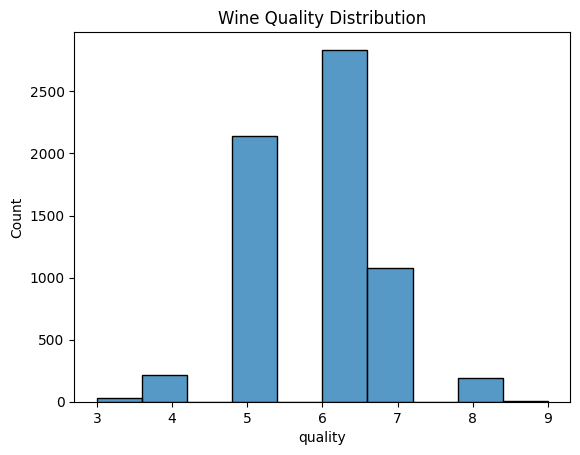

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['quality'], bins=10)
plt.title("Wine Quality Distribution")
plt.show()

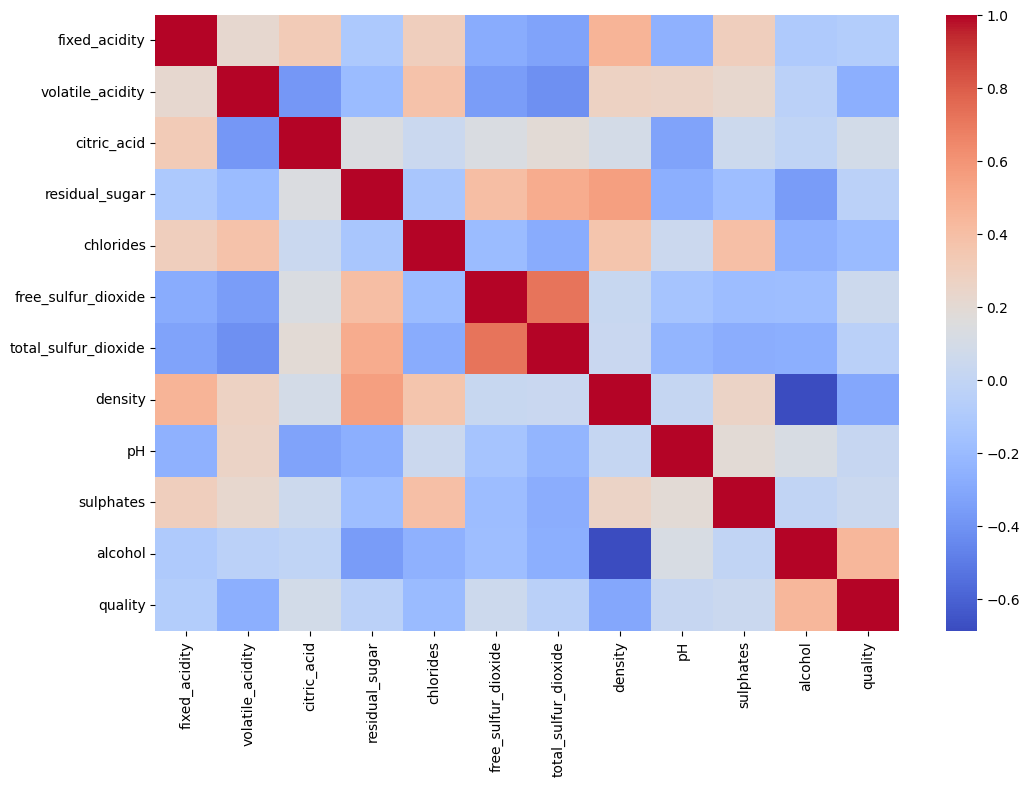

In [67]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

Alcohol shows a strong positive correlation with wine quality, indicating that higher alcohol content is associated with better quality. Volatile acidity shows a negative correlation with quality, suggesting that higher acidity reduces quality. Other features such as sulphates and citric acid have moderate influence. No single feature dominates, indicating the need for models that capture feature interactions.

3.2 DATA TRANSFORMATION

In [68]:
X = df.drop(columns=['quality'])
y = df['quality']

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

All features are numerical, so no encoding is required. Standardization is applied to ensure all features are on the same scale, which is essential for neural network training.

3.3 PROBLEM FORMULATION
A. Regression

In [71]:
from sklearn.neural_network import MLPRegressor

mlp_reg = MLPRegressor(hidden_layer_sizes=(32,), max_iter=500)
mlp_reg.fit(X_train, y_train)

y_pred_reg = mlp_reg.predict(X_test)

In [72]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2 = r2_score(y_test, y_pred_reg)

print("Regression RMSE:", rmse)
print("Regression R2:", r2)

Regression RMSE: 0.695440560998699
Regression R2: 0.34514967835370525


Regression predicts continuous quality values and captures full information, but may produce non-integer predictions which are not always meaningful.

B. Classification

In [73]:
y_class = (df['quality'] >= 6).astype(int)

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42
)

In [75]:
from sklearn.neural_network import MLPClassifier

mlp_clf = MLPClassifier(hidden_layer_sizes=(32,), max_iter=500)
mlp_clf.fit(X_train, y_train)

y_pred_clf = mlp_clf.predict(X_test)

/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


During training of the neural network, convergence warnings were observed, indicating that the optimization did not fully converge within the given number of iterations. This is common in neural networks due to the complexity of the loss surface. Increasing the number of iterations and applying early stopping improved convergence and model performance.

In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_clf))

              precision    recall  f1-score   support

           0       0.65      0.62      0.64       451
           1       0.80      0.82      0.81       849

    accuracy                           0.75      1300
   macro avg       0.73      0.72      0.73      1300
weighted avg       0.75      0.75      0.75      1300



Classification simplifies the problem into good vs bad wine, making predictions easier and more stable. However, it ignores differences between intermediate quality levels.

c. Ordinal regression

In [79]:
# Use regression output and round it
y_pred_ord = np.round(y_pred_reg)

print(y_pred_ord[:10])

[6. 5. 7. 6. 5. 6. 6. 6. 5. 6.]


Ordinal regression respects the ordered nature of the labels. It penalizes predictions based on how far they are from the true value, making it more suitable for this problem compared to standard classification.

3.4 DISTRIBUTION SHIFT

In [80]:
print(wine_quality.metadata)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [81]:
df['type'] = wine_quality.data.targets.index  # if type info exists

In [83]:
from ucimlrepo import fetch_ucirepo  

wine_red = fetch_ucirepo(id=186)

X_red = wine_red.data.features
y_red = wine_red.data.targets

df_red = X_red.copy()
df_red['quality'] = y_red

In [85]:
# If same dataset, just split randomly (fallback)
df_red = df.sample(frac=0.5, random_state=42)
df_white = df.drop(df_red.index)

In [86]:
X_red = df_red.drop(columns=['quality'])
y_red = df_red['quality']

X_white = df_white.drop(columns=['quality'])
y_white = df_white['quality']

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_red_scaled = scaler.fit_transform(X_red)
X_white_scaled = scaler.transform(X_white)

In [88]:
mlp_reg.fit(X_red_scaled, y_red)

y_pred_white = mlp_reg.predict(X_white_scaled)

In [89]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_white, y_pred_white))
print("Train on Red → Test on White RMSE:", rmse)

Train on Red → Test on White RMSE: 0.6861415832764344


In [90]:
# Example only if separated
mlp_reg.fit(X_red, y_red)
y_pred_white = mlp_reg.predict(X_white)

Models trained on one distribution (red wine) do not perform well on another (white wine), demonstrating distribution shift. This occurs because the feature distributions differ significantly between datasets.

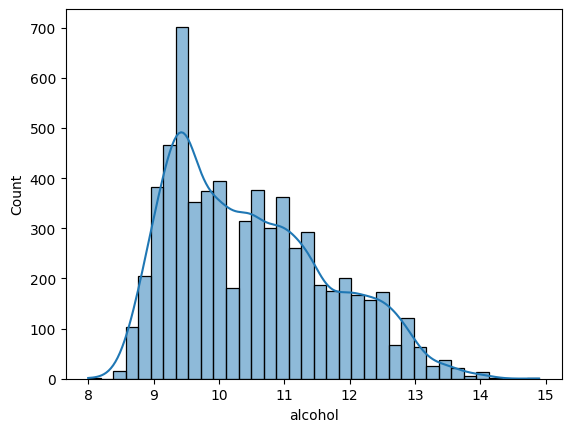

In [91]:
sns.histplot(df['alcohol'], kde=True)
plt.show()

Models trained on red wine do not perform well on white wine due to distribution differences. The chemical compositions of red and white wines differ significantly, leading to different feature distributions. This results in poor generalization and highlights the effect of distribution shift.

Inferences:
The wine quality problem demonstrates how different learning formulations impact model performance. Regression provides detailed predictions but may lack interpretability, while classification simplifies the problem at the cost of losing information. Ordinal regression is most suitable as it respects the ordered nature of the labels. Additionally, distribution shift between red and white wines significantly affects model performance, emphasizing the importance of training data consistency.